In [ ]:
# ============================================================
# LAB EXPERIMENT 1
# SAFE GOOGLE COLAB ENVIRONMENT SETUP
# ============================================================

# Install ONLY the packages that Colab does not already provide.
# Pin WFDB to a version compatible with Colab's pandas.

!pip -q install ucimlrepo==0.0.7 wfdb==4.1.2

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import wfdb

print("Environment setup completed successfully.")

print("NumPy version      :", np.__version__)
print("Pandas version     :", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("WFDB version       :", wfdb.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 2.3 MB/s eta 0:00:00
Environment setup completed successfully.
NumPy version      : 2.0.2
Pandas version     : 2.2.2
Scikit-learn version: 1.6.1
WFDB version       : 4.1.2


In [ ]:
# ============================================================
# PART 1A: Load UCI Heart Disease Dataset
# ============================================================

from ucimlrepo import fetch_ucirepo

# Fetch official UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

# Input features
X = heart_disease.data.features.copy()

# Target
y_original = heart_disease.data.targets.copy()

print("Dataset loaded successfully.")

print("\nInput data shape:")
print(X.shape)

print("\nTarget shape:")
print(y_original.shape)

#print("\nFirst 5 rows of input data:")
#display(X.head())
display(X)

#print("\nFirst 5 target values:")
display(y_original)

Dataset loaded successfully.

Input data shape:
(303, 13)

Target shape:
(303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0


,num
0,0
1,2
2,1
3,0
4,0
...,...
298,1
299,2
300,3
301,1


In [ ]:
# ============================================================
# PART 1B: Dataset Inspection
# ============================================================

print("Column names:")
print(X.columns.tolist())

print("\nDataset dimensions:")
print("Number of patients:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nData types:")
print(X.dtypes)

print("\nGeneral information:")
X.info()

print("\nStatistical summary:")
display(X.describe(include="all"))

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Dataset dimensions:
Number of patients: 303
Number of features: 13

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

General information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [ ]:
# ============================================================
# PART 1C: Missing Value Analysis
# ============================================================

print("Missing values in each feature:")
missing_values = X.isnull().sum()

print(missing_values)

print("\nTotal missing values:")
print(X.isnull().sum().sum())

Missing values in each feature:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Total missing values:
6


In [ ]:
print("Features containing missing values:")

missing_only = X.isnull().sum()
missing_only = missing_only[missing_only > 0]

print(missing_only)

Features containing missing values:
ca      4
thal    2
dtype: int64


In [ ]:
# ============================================================
# PART 1D: Convert Target to Binary
# ============================================================

target_column = y_original.columns[0]

print("Original target column:", target_column)

print("\nOriginal target distribution:")
print(y_original[target_column].value_counts().sort_index())

# Convert target to numeric
target_numeric = pd.to_numeric(
    y_original[target_column],
    errors="coerce"
)

# Binary conversion
# 0 -> no disease
# 1,2,3,4 -> disease present

y = (target_numeric > 0).astype(int)

y.name = "heart_disease"

print("\nBinary target distribution:")
print(y.value_counts())

print("\n0 = No Heart Disease")
print("1 = Heart Disease Present")

Original target column: num

Original target distribution:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Binary target distribution:
heart_disease
0    164
1    139
Name: count, dtype: int64

0 = No Heart Disease
1 = Heart Disease Present


heart_disease
0    164
1    139
Name: count, dtype: int64


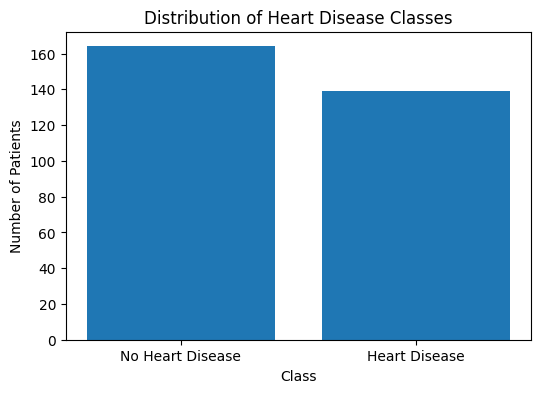

In [ ]:
# ============================================================
# PART 1E: Class Distribution
# ============================================================

class_counts = y.value_counts().sort_index()

print(class_counts)

plt.figure(figsize=(6, 4))
plt.bar(
    ["No Heart Disease", "Heart Disease"],
    [class_counts.get(0, 0), class_counts.get(1, 0)]
)

plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.title("Distribution of Heart Disease Classes")
plt.show()

In [ ]:
# ============================================================
# PART 1G: Correlation Analysis
# ============================================================

# Convert all columns to numeric where possible
numeric_X = X.apply(pd.to_numeric, errors="coerce")

# Add binary target
correlation_data = numeric_X.copy()
correlation_data["heart_disease"] = y.values

# Calculate correlation
correlation_matrix = correlation_data.corr()

print("Correlation Matrix:")
display(correlation_matrix.round(2))

Correlation Matrix:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,heart_disease
age,1.00,-0.10,0.10,0.28,0.21,0.12,0.15,-0.39,0.09,0.20,0.16,0.36,0.13,0.22
sex,-0.10,1.00,0.01,-0.06,-0.20,0.05,0.02,-0.05,0.15,0.10,0.04,0.09,0.38,0.28
cp,0.10,0.01,1.00,-0.04,0.07,-0.04,0.07,-0.33,0.38,0.20,0.15,0.23,0.27,0.41
trestbps,0.28,-0.06,-0.04,1.00,0.13,0.18,0.15,-0.05,0.06,0.19,0.12,0.10,0.13,0.15
chol,0.21,-0.20,0.07,0.13,1.00,0.01,0.17,-0.00,0.06,0.05,-0.00,0.12,0.01,0.09
fbs,0.12,0.05,-0.04,0.18,0.01,1.00,0.07,-0.01,0.03,0.01,0.06,0.15,0.07,0.03
restecg,0.15,0.02,0.07,0.15,0.17,0.07,1.00,-0.08,0.08,0.11,0.13,0.13,0.02,0.17
thalach,-0.39,-0.05,-0.33,-0.05,-0.00,-0.01,-0.08,1.00,-0.38,-0.34,-0.39,-0.26,-0.28,-0.42
exang,0.09,0.15,0.38,0.06,0.06,0.03,0.08,-0.38,1.00,0.29,0.26,0.15,0.33,0.43
oldpeak,0.20,0.10,0.20,0.19,0.05,0.01,0.11,-0.34,0.29,1.00,0.58,0.30,0.34,0.42


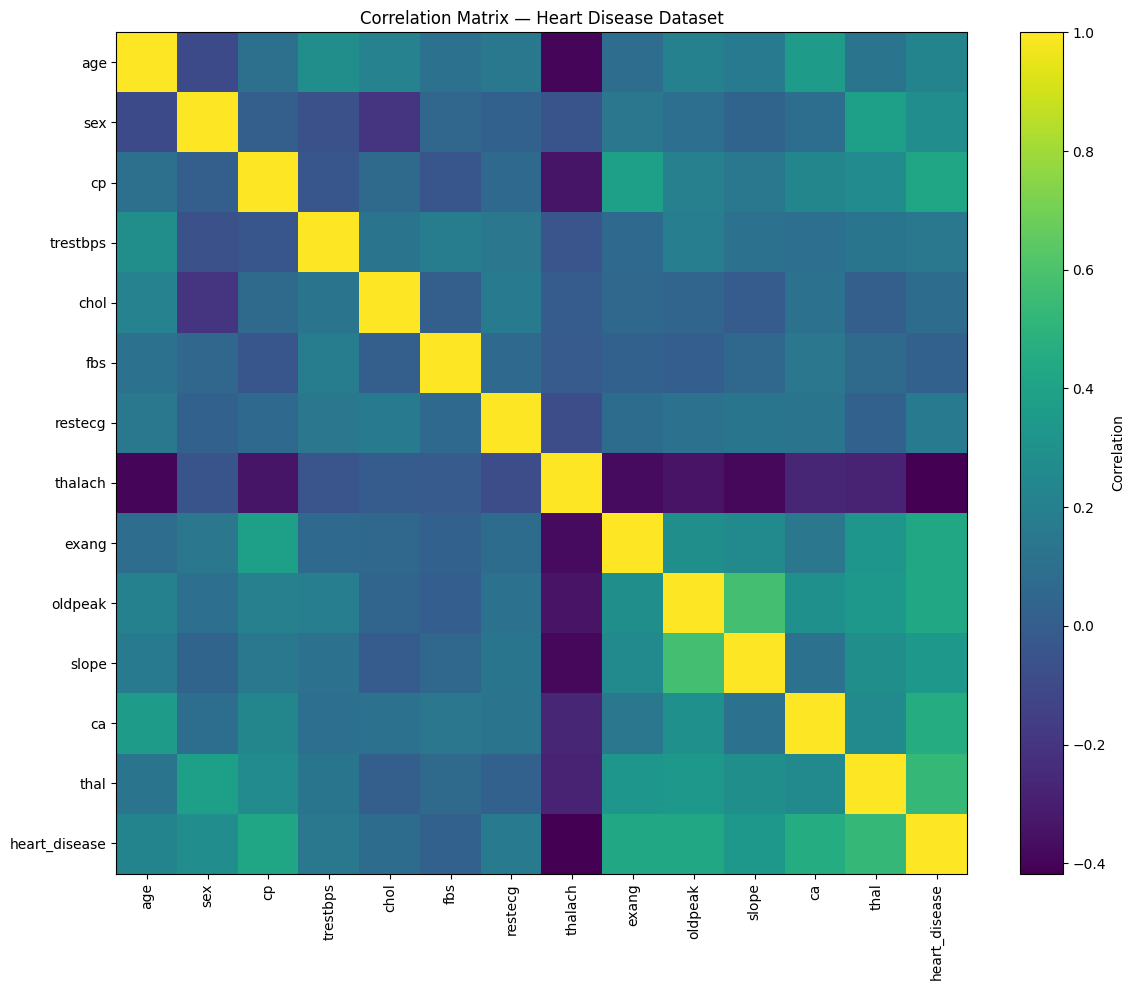

In [ ]:
plt.figure(figsize=(12, 10))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix — Heart Disease Dataset")
plt.tight_layout()
plt.show()

In [ ]:
print(
    correlation_matrix["heart_disease"]
    .sort_values(ascending=False)
)

heart_disease    1.000000
thal             0.525689
ca               0.460442
exang            0.431894
oldpeak          0.424510
cp               0.414446
slope            0.339213
sex              0.276816
age              0.223120
restecg          0.169202
trestbps         0.150825
chol             0.085164
fbs              0.025264
thalach         -0.417167
Name: heart_disease, dtype: float64


In [ ]:
# ============================================================
# PART 1H: Identify Numerical and Categorical Features
# ============================================================

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

# Keep only columns that actually exist
numerical_features = [
    col for col in numerical_features
    if col in X.columns
]

categorical_features = [
    col for col in categorical_features
    if col in X.columns
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Categorical Features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [ ]:
# ============================================================
# PART 1I: Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training samples: 242
Testing samples: 61

Training shape: (242, 13)
Testing shape: (61, 13)


In [ ]:
# ============================================================
# PART 1J: Data Preprocessing
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [ ]:
# ============================================================
# PART 1K: Logistic Regression Model
# ============================================================

from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# ============================================================
# PART 1L: Prediction
# ============================================================

y_pred = model.predict(X_test)

# Probability of heart disease
y_probability = model.predict_proba(X_test)[:, 1]

print("First 10 predicted classes:")
print(y_pred[:10])
print(y_pred)

print("\nFirst 10 predicted probabilities:")
print(y_probability[:10])
print(y_probability)

First 10 predicted classes:
[0 1 0 0 0 0 0 0 1 0]
[0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 0 1 1 1 0 1 0
 0 0 1 1 1 1 1 0 0 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1]

First 10 predicted probabilities:
[0.20929567 0.60145782 0.02148916 0.03334708 0.3118407  0.01557081
 0.11681799 0.34861394 0.72209751 0.34742282]
[0.20929567 0.60145782 0.02148916 0.03334708 0.3118407  0.01557081
 0.11681799 0.34861394 0.72209751 0.34742282 0.96562059 0.02352735
 0.03427722 0.92799701 0.96827571 0.97890539 0.76590796 0.69300695
 0.70923836 0.97914056 0.72760374 0.04208378 0.84520128 0.23347798
 0.8115307  0.03938699 0.0903792  0.84562802 0.08436408 0.970595
 0.34885686 0.94051621 0.50786951 0.53170869 0.14601116 0.90067712
 0.19418282 0.26673102 0.03898709 0.8588818  0.85699284 0.98976197
 0.9817895  0.9468737  0.13415838 0.02757432 0.93762067 0.02694372
 0.98872108 0.09762274 0.0236043  0.98872836 0.48730039 0.05659382
 0.43752918 0.96712624 0.90997278 0.69666797 0.01324408 0.03647952
 0.967955

In [ ]:
# ============================================================
# PART 1M: Model Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probability)

print("Accuracy:")
print(round(accuracy, 4))

print("\nROC-AUC:")
print(round(auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

Accuracy:
0.8852

ROC-AUC:
0.9665

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.93      0.85      0.89        33
   Heart Disease       0.84      0.93      0.88        28

        accuracy                           0.89        61
       macro avg       0.89      0.89      0.89        61
    weighted avg       0.89      0.89      0.89        61



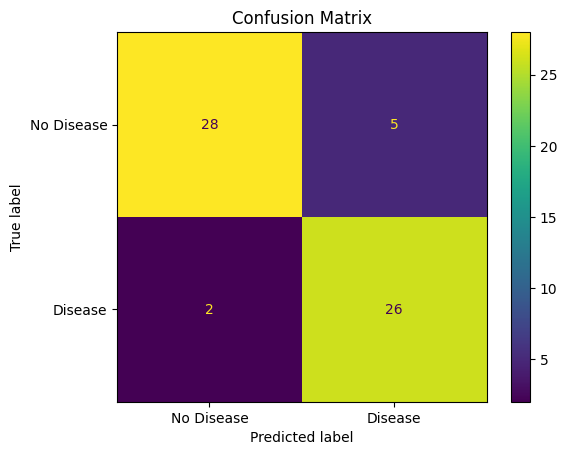

In [ ]:
# ============================================================
# PART 1N: Confusion Matrix
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "No Disease",
        "Disease"
    ]
)

plt.title("Confusion Matrix")
plt.show()

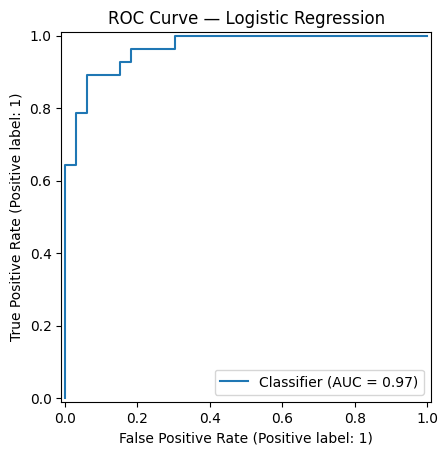

In [ ]:
# ============================================================
# PART 1O: ROC Curve
# ============================================================

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title("ROC Curve — Logistic Regression")
plt.show()